<a href="https://colab.research.google.com/github/jwliu24/Uber-Operational-Analysis/blob/main/Week_3_Exploratory_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Exploratory Data Analysis


---
In this session, you will:
- Explore the dataset visually
- Understand booking outcomes and success patterns
- Practice asking questions and answerinng them with plots


### Setups & Imports

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

### Load the dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Update the file path below to match where your processed dataset from Week 2 is stored
# Example: '/content/drive/MyDrive/build-project/uber_rides_data.csv'
file_path = '/content/drive/MyDrive/Colab Notebooks/uber_rides_data.csv'


processed_df = pd.read_csv(file_path)

# Display the first few rows of the dataset
processed_df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Payment Method,is_successful,is_cancelled_customer,is_cancelled_driver,is_incomplete,DateTime,Hour,DayOfWeek,Month,IsWeekend
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,False,False,False,False,2024-03-23 12:29:38,12,Saturday,3,True
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,UPI,False,False,False,True,2024-11-29 18:01:39,18,Friday,11,False
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,Debit Card,True,False,False,False,2024-08-23 08:56:10,8,Friday,8,False
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,UPI,True,False,False,False,2024-10-21 17:17:25,17,Monday,10,False
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,UPI,True,False,False,False,2024-09-16 22:08:00,22,Monday,9,False


In [4]:
processed_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 30 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

### Original Data Schema

| Column Name                           | Description                                                                         |
| ------------------------------------- | ----------------------------------------------------------------------------------- |
| **Date**                              | Date of the booking                                                                 |
| **Time**                              | Time of the booking                                                                 |
| **Booking ID**                        | Unique identifier for each ride booking                                             |
| **Booking Status**                    | Status of the booking (Completed, Cancelled by Customer, Cancelled by Driver, etc.) |
| **Customer ID**                       | Unique identifier for customers                                                     |
| **Vehicle Type**                      | Type of vehicle (Go Mini, Go Sedan, Auto, eBike/Bike, UberXL, Premier Sedan)        |
| **Pickup Location**                   | Starting location of the ride                                                       |
| **Drop Location**                     | Destination location of the ride                                                    |
| **Avg VTAT**                          | Average time for driver to reach pickup location (in minutes)                       |
| **Avg CTAT**                          | Average trip duration from pickup to destination (in minutes)                       |
| **Cancelled Rides by Customer**       | Flag indicating customer-initiated cancellation                                     |
| **Reason for cancelling by Customer** | Reason provided for customer cancellation                                           |
| **Cancelled Rides by Driver**         | Flag indicating driver-initiated cancellation                                       |
| **Driver Cancellation Reason**        | Reason provided for driver cancellation                                             |
| **Incomplete Rides**                  | Flag indicating incomplete rides                                                    |
| **Incomplete Rides Reason**           | Reason for incomplete rides                                                         |
| **Booking Value**                     | Total fare amount for the ride                                                      |
| **Ride Distance**                     | Distance covered during the ride (in kilometers)                                    |
| **Driver Ratings**                    | Rating given to the driver (1–5 scale)                                              |
| **Customer Rating**                   | Rating given by the customer (1–5 scale)                                            |
| **Payment Method**                    | Method used for payment (UPI, Cash, Credit Card, Uber Wallet, Debit Card)           |

### New columns

| Column Name                           | Description                                                                         |
| ------------------------------------- | ----------------------------------------------------------------------------------- |
| **is_successful**                              | Flag indicating whether ride was successful                                                                 |
| **is_cancelled_customer**                              | Flag indicating whether ride cancelled by customer|
| **is_cancelled_driver**                        | Flag indicating whether ride cancelled by driver|
| **is_incomplete**                    | Flag indicating whether ride was incomplete |
| **Datetime**                    | Combination of date and time columns |
| **Hour**                    | Hour value extracted from time |
| **DayOfWeek**                    | Week day extracted from date |
| **Month**                    | Month number extracted from date |
| **IsWeekend**                    | Flag indicating if date is weekend |

#### Missing Data Analysis

In [5]:
missing_data = processed_df.isnull().sum()

In [6]:
missing_percentage = (missing_data / len(processed_df)) * 100

In [7]:
missing_df = pd.DataFrame({'Missing Count': missing_data, 'Missing Percentage': missing_percentage}).sort_values('Missing Count', ascending=False)

In [8]:
missing_df

,Missing Count,Missing Percentage
Incomplete Rides Reason,141000,94.0
Incomplete Rides,141000,94.0
Cancelled Rides by Customer,139500,93.0
Reason for cancelling by Customer,139500,93.0
Cancelled Rides by Driver,123000,82.0
Driver Cancellation Reason,123000,82.0
Driver Ratings,57000,38.0
Customer Rating,57000,38.0
Booking Value,48000,32.0
Ride Distance,48000,32.0


In [9]:
missing_df[missing_df['Missing Count'] > 0]

,Missing Count,Missing Percentage
Incomplete Rides Reason,141000,94.0
Incomplete Rides,141000,94.0
Cancelled Rides by Customer,139500,93.0
Reason for cancelling by Customer,139500,93.0
Cancelled Rides by Driver,123000,82.0
Driver Cancellation Reason,123000,82.0
Driver Ratings,57000,38.0
Customer Rating,57000,38.0
Booking Value,48000,32.0
Ride Distance,48000,32.0


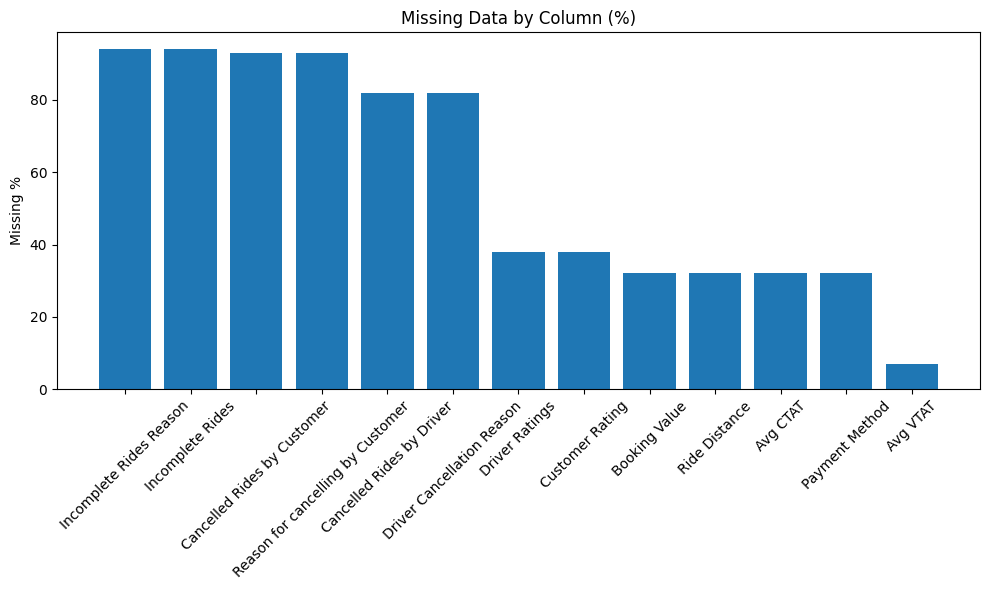

In [10]:
plt.figure(figsize=(10,6))
missing_cols = missing_df[missing_df['Missing Count'] > 0]
plt.bar(missing_cols.index, missing_cols['Missing Percentage'])
plt.title('Missing Data by Column (%)')
plt.ylabel('Missing %')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Explore Numeric Columns

In [11]:
numeric_cols = processed_df.select_dtypes(include=['int64', 'float64']).columns
numeric_cols

Index(['Avg VTAT', 'Avg CTAT', 'Cancelled Rides by Customer',
       'Cancelled Rides by Driver', 'Incomplete Rides', 'Booking Value',
       'Ride Distance', 'Driver Ratings', 'Customer Rating', 'Hour', 'Month'],
      dtype='object')

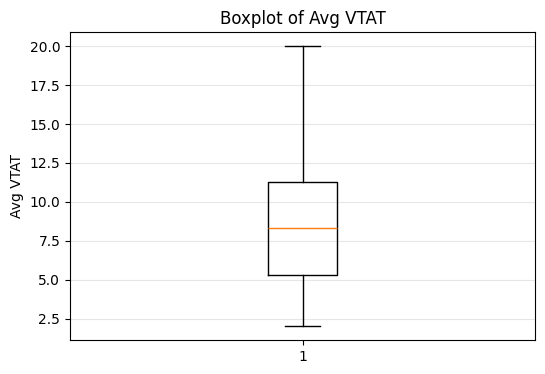

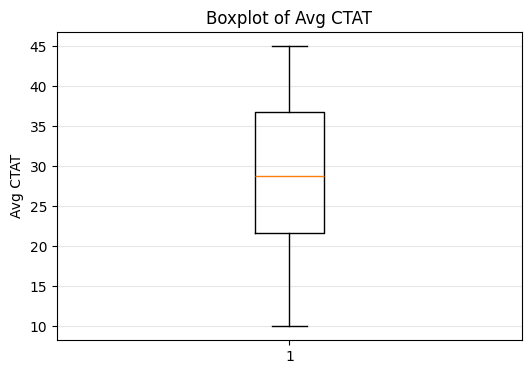

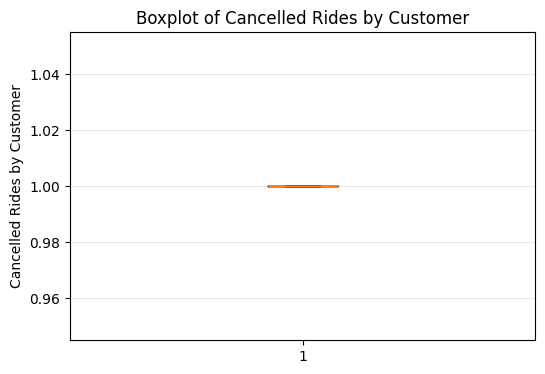

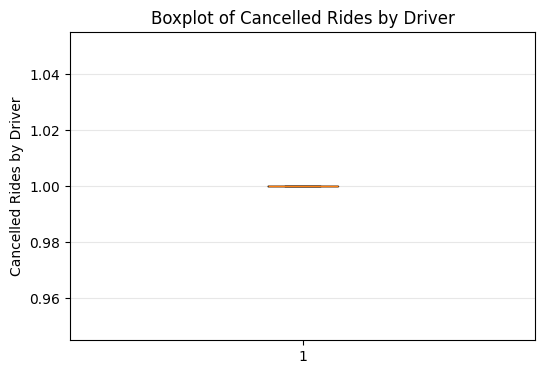

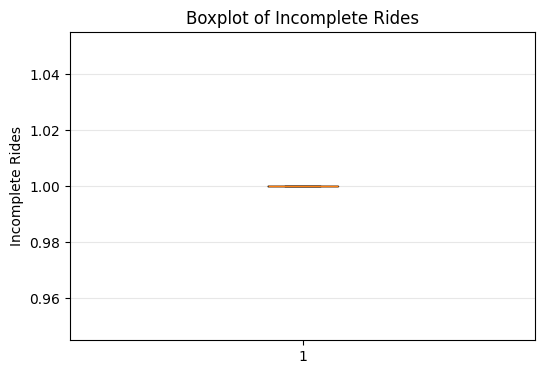

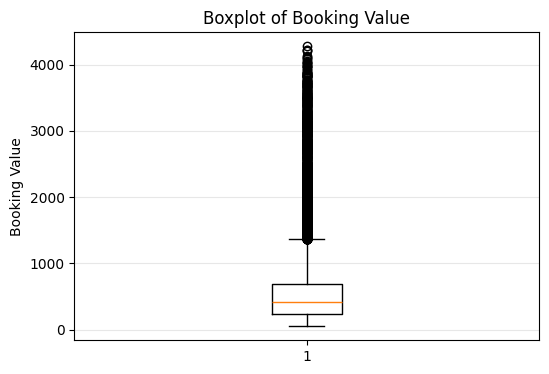

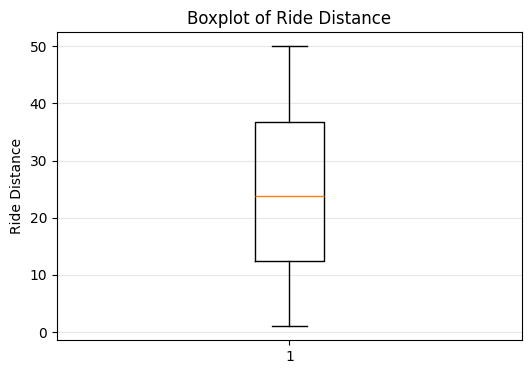

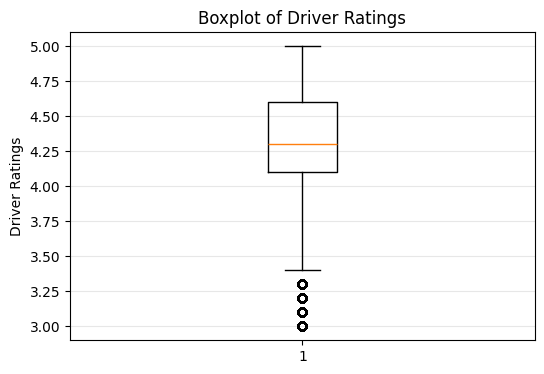

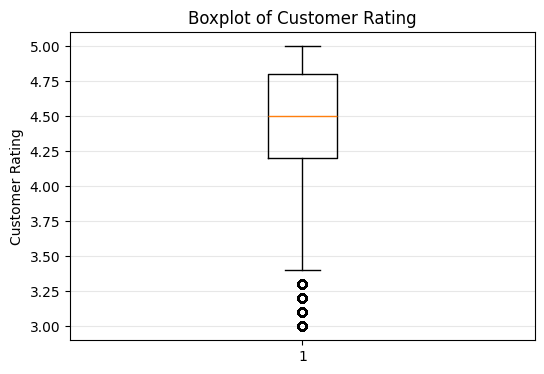

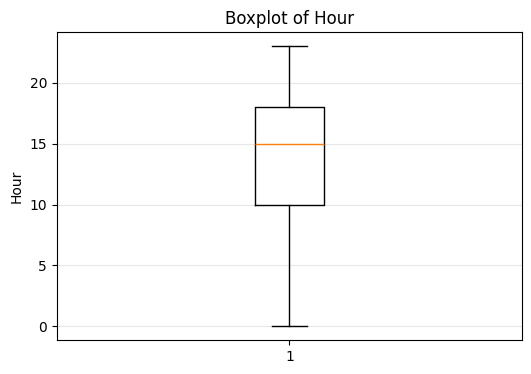

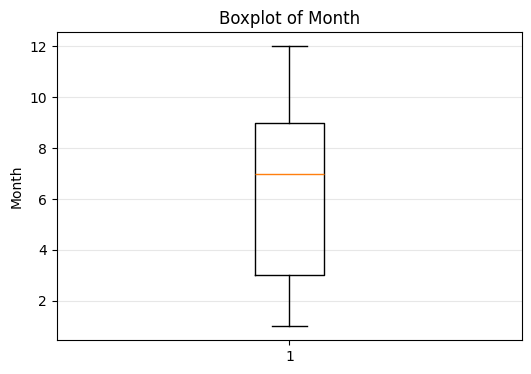

In [12]:
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    plt.boxplot(processed_df[col].dropna())
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.grid(axis='y', alpha=0.3)
    plt.show()

In [13]:
numeric_cols = ['Avg VTAT', 'Avg CTAT', 'Booking Value',
       'Ride Distance', 'Driver Ratings', 'Customer Rating', 'Hour', 'Month']
processed_df[numeric_cols].corr()

,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Hour,Month
Avg VTAT,1.000000,0.062175,0.002259,0.063005,-0.005439,-0.003945,-0.004335,0.002737
Avg CTAT,0.062175,1.000000,0.000216,0.101503,0.000807,0.001000,-0.001295,-0.000465
Booking Value,0.002259,0.000216,1.000000,0.005174,-0.000249,-0.000287,-0.001292,0.002200
Ride Distance,0.063005,0.101503,0.005174,1.000000,-0.001875,0.004514,-0.002560,0.004835
Driver Ratings,-0.005439,0.000807,-0.000249,-0.001875,1.000000,-0.001010,-0.000084,-0.000920
Customer Rating,-0.003945,0.001000,-0.000287,0.004514,-0.001010,1.000000,-0.002358,-0.002298
Hour,-0.004335,-0.001295,-0.001292,-0.002560,-0.000084,-0.002358,1.000000,0.000369
Month,0.002737,-0.000465,0.002200,0.004835,-0.000920,-0.002298,0.000369,1.000000


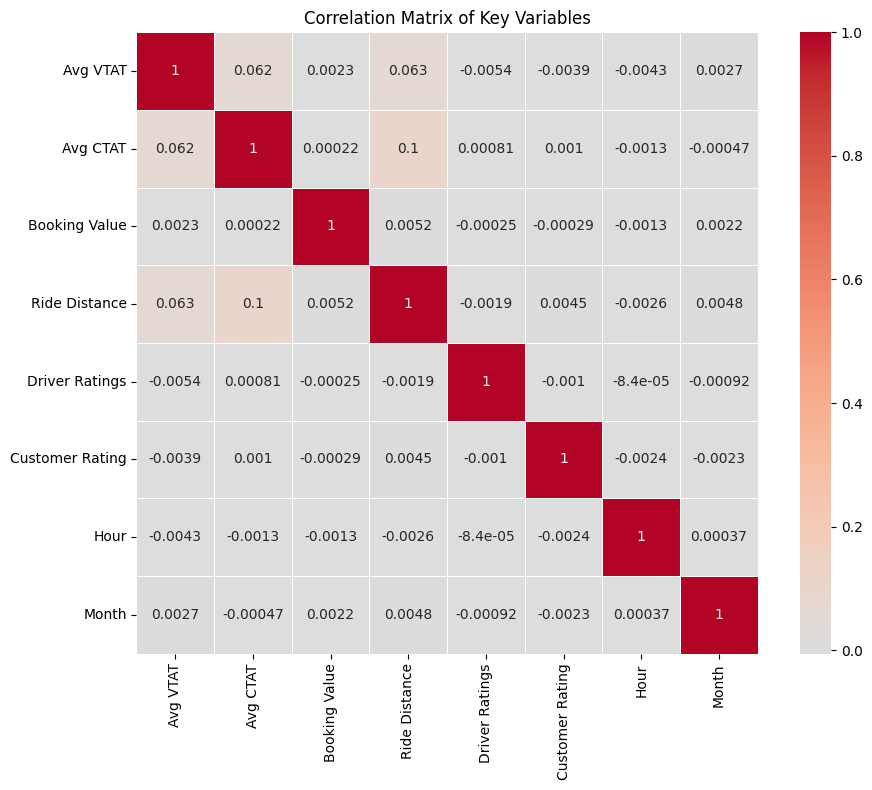

In [14]:
plt.figure(figsize=(10, 8))
sns.heatmap(processed_df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix of Key Variables')
plt.tight_layout()
plt.show()

### Answer questions using data

When starting Exploratory Data Analysis (EDA), it’s easy to feel overwhelmed by the number of directions you could explore. A helpful strategy is to start with a single, well-defined question instead of trying to analyze everything at once.

For this example, we’ll focus on **ride cancellations**.

Our goal is to understand whether certain features—such as *vehicle type*, *time of day*, or *day of the week*—may influence cancellations more than others. To do this, we’ll first filter the dataset to include only cancelled rides. Then, we’ll explore key features within this subset to look for patterns, trends, and potential drivers of cancellations.




In [15]:
cancelled_data = processed_df[(processed_df.is_cancelled_customer == True) | (processed_df.is_cancelled_driver == True)]

In [16]:
cancelled_data.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Payment Method,is_successful,is_cancelled_customer,is_cancelled_driver,is_incomplete,DateTime,Hour,DayOfWeek,Month,IsWeekend
12,2024-06-25,22:44:15,"""CNR4386945""",Cancelled by Driver,"""CID5543520""",eBike,Patel Chowk,Kherki Daula Toll,4.6,NaN,...,NaN,False,False,True,False,2024-06-25 22:44:15,22,Tuesday,6,False
17,2024-12-15,15:08:25,"""CNR6739317""",Cancelled by Driver,"""CID8682675""",Go Sedan,Vinobapuri,GTB Nagar,6.0,NaN,...,NaN,False,False,True,False,2024-12-15 15:08:25,15,Sunday,12,True
18,2024-11-24,09:07:10,"""CNR6126048""",Cancelled by Customer,"""CID1060329""",eBike,Kashmere Gate,Anand Vihar,12.4,NaN,...,NaN,False,True,False,False,2024-11-24 09:07:10,9,Sunday,11,True
19,2024-05-24,19:53:57,"""CNR9465840""",Cancelled by Driver,"""CID9046501""",eBike,Pitampura,Rajiv Nagar,10.3,NaN,...,NaN,False,False,True,False,2024-05-24 19:53:57,19,Friday,5,False
26,2024-01-26,09:44:00,"""CNR3614535""",Cancelled by Driver,"""CID2507102""",Auto,Cyber Hub,Saket,11.5,NaN,...,NaN,False,False,True,False,2024-01-26 09:44:00,9,Friday,1,False


In [17]:
cancelled_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37500 entries, 12 to 149990
Data columns (total 30 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Date                               37500 non-null  object 
 1   Time                               37500 non-null  object 
 2   Booking ID                         37500 non-null  object 
 3   Booking Status                     37500 non-null  object 
 4   Customer ID                        37500 non-null  object 
 5   Vehicle Type                       37500 non-null  object 
 6   Pickup Location                    37500 non-null  object 
 7   Drop Location                      37500 non-null  object 
 8   Avg VTAT                           37500 non-null  float64
 9   Avg CTAT                           0 non-null      float64
 10  Cancelled Rides by Customer        10500 non-null  float64
 11  Reason for cancelling by Customer  10500 non-null  object

#### Cancellations by Vehicle Types

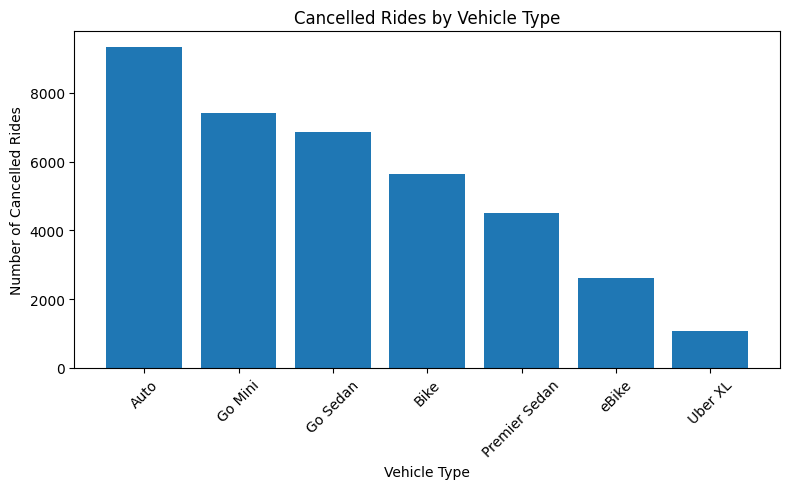

In [18]:
vehicle_counts = cancelled_data['Vehicle Type'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(vehicle_counts.index, vehicle_counts.values)
plt.title('Cancelled Rides by Vehicle Type')
plt.xlabel('Vehicle Type')
plt.ylabel('Number of Cancelled Rides')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### What are the key takeaways from this chart?

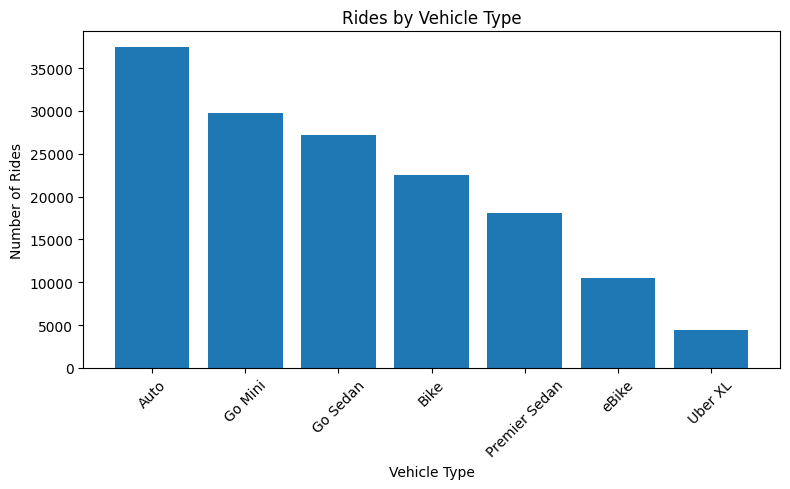

In [19]:
vehicle_counts = processed_df['Vehicle Type'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(vehicle_counts.index, vehicle_counts.values)
plt.title('Rides by Vehicle Type')
plt.xlabel('Vehicle Type')
plt.ylabel('Number of Rides')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
cancellation_rate_vehicle = (
    processed_df.groupby('Vehicle Type')['is_successful']
    .count()
)

cancel_counts = cancelled_data['Vehicle Type'].value_counts()

cancellation_rate = (cancel_counts / cancellation_rate_vehicle) * 100
cancellation_rate.sort_values(ascending=False)

,0
Vehicle Type,
Go Sedan,25.286467
Bike,25.101035
Premier Sedan,24.935122
Go Mini,24.917802
Auto,24.915150
eBike,24.912380
Uber XL,24.477411


#### Customer vs Driver Cancellation

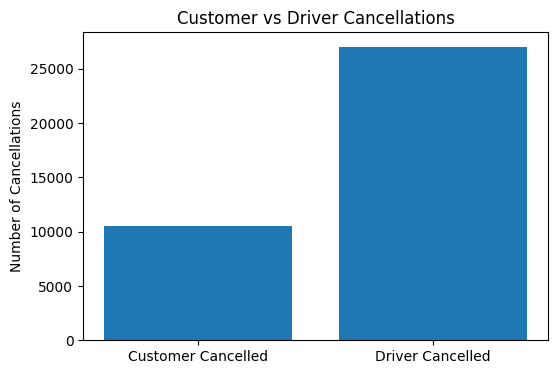

In [21]:
cancel_type_counts = cancelled_data[['is_cancelled_customer', 'is_cancelled_driver']].sum()

plt.figure(figsize=(6, 4))
plt.bar(['Customer Cancelled', 'Driver Cancelled'], cancel_type_counts.values)
plt.title('Customer vs Driver Cancellations')
plt.ylabel('Number of Cancellations')
plt.show()

##### What actions can you take next based on the chart?

##### Reasons for Cancellations

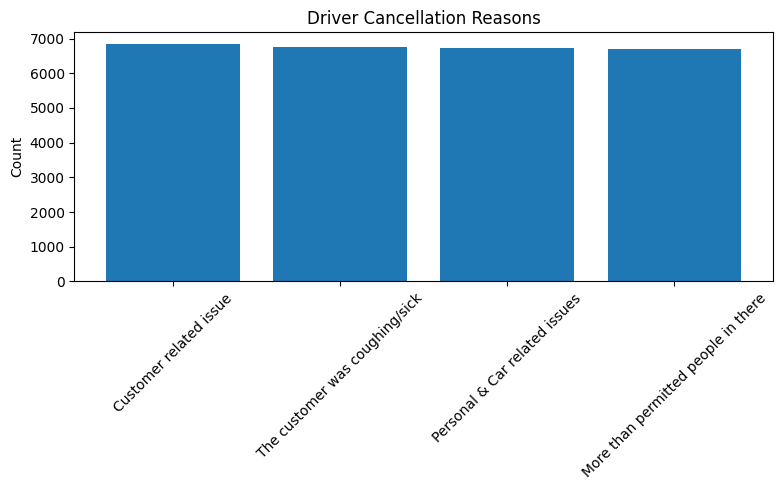

In [22]:
driver_reasons = cancelled_data['Driver Cancellation Reason'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(driver_reasons.index, driver_reasons.values)
plt.title('Driver Cancellation Reasons')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

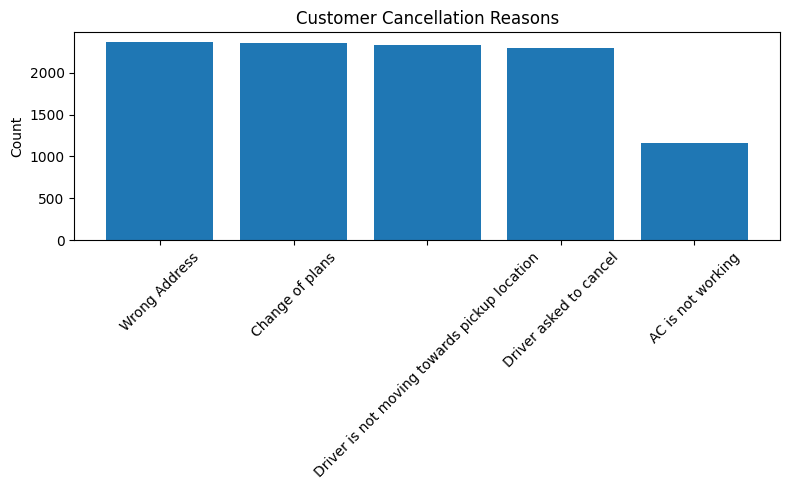

In [23]:
customer_reasons = cancelled_data['Reason for cancelling by Customer'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(customer_reasons.index, customer_reasons.values)
plt.title('Customer Cancellation Reasons')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### Cancellations by Day of Week

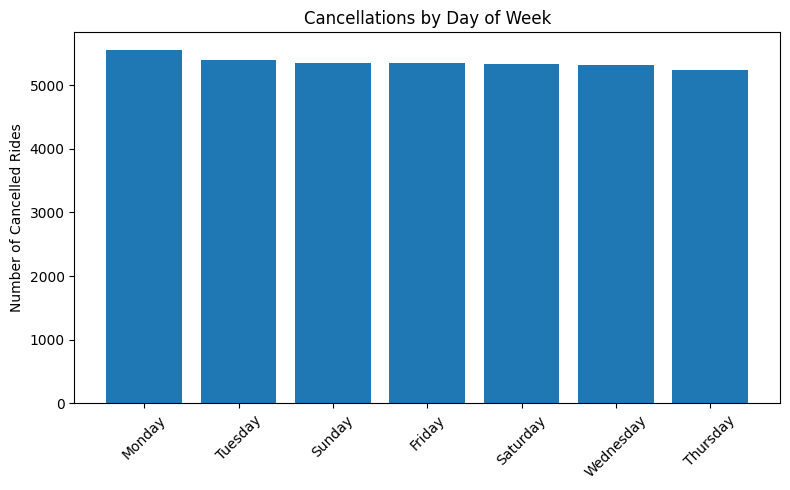

In [24]:
day_counts = cancelled_data['DayOfWeek'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(day_counts.index, day_counts.values)
plt.title('Cancellations by Day of Week')
plt.ylabel('Number of Cancelled Rides')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

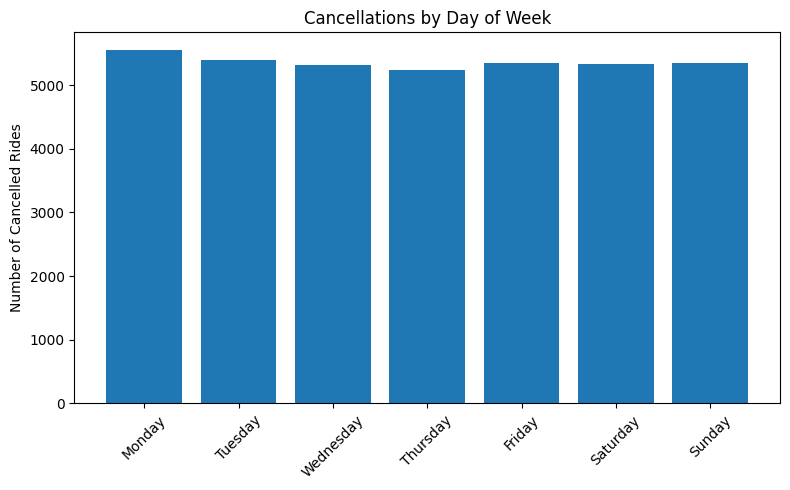

In [25]:
# Optional: reorder days
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_counts = day_counts.reindex(day_order)

plt.figure(figsize=(8, 5))
plt.bar(day_counts.index, day_counts.values)
plt.title('Cancellations by Day of Week')
plt.ylabel('Number of Cancelled Rides')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
weekend_counts = cancelled_data['IsWeekend'].value_counts()
weekend_counts

,count
IsWeekend,
False,26829
True,10671



#### Cancellations by Hour of Day

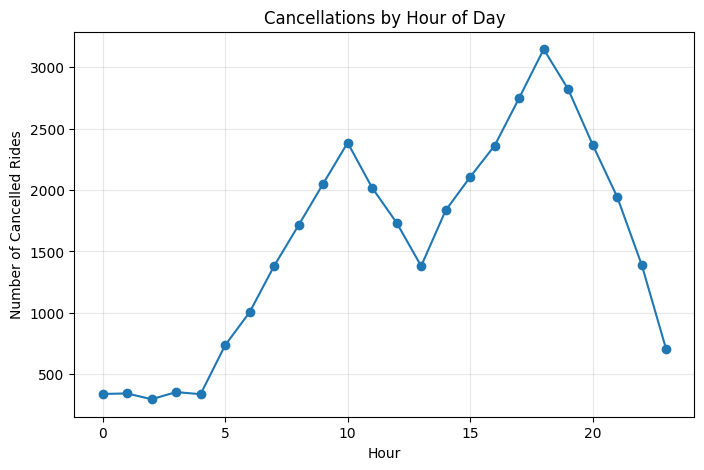

In [27]:
hour_counts = cancelled_data['Hour'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.plot(hour_counts.index, hour_counts.values, marker='o')
plt.title('Cancellations by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Number of Cancelled Rides')
plt.grid(alpha=0.3)
plt.show()



#### Do cancellations follow a time-based pattern or trend?



In [28]:
cancelled_data['DateTime'] = pd.to_datetime(cancelled_data['DateTime'])


/tmp/ipython-input-2063688314.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cancelled_data['DateTime'] = pd.to_datetime(cancelled_data['DateTime'])


In [29]:
daily_cancellations = cancelled_data.groupby(cancelled_data['DateTime'].dt.date).size()

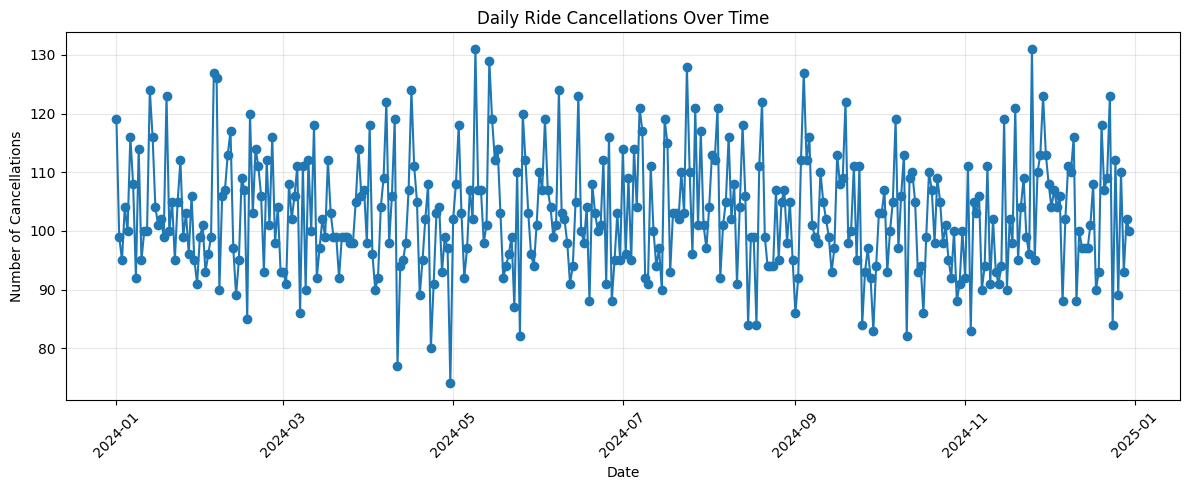

In [30]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_cancellations.index,
    daily_cancellations.values,
    marker='o',
    linestyle='-'
)

plt.title('Daily Ride Cancellations Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Cancellations')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



> Are there are any monthly trends in cancellation?



In [31]:
monthly_cancellations = cancelled_data.groupby(cancelled_data['DateTime'].dt.month).size()

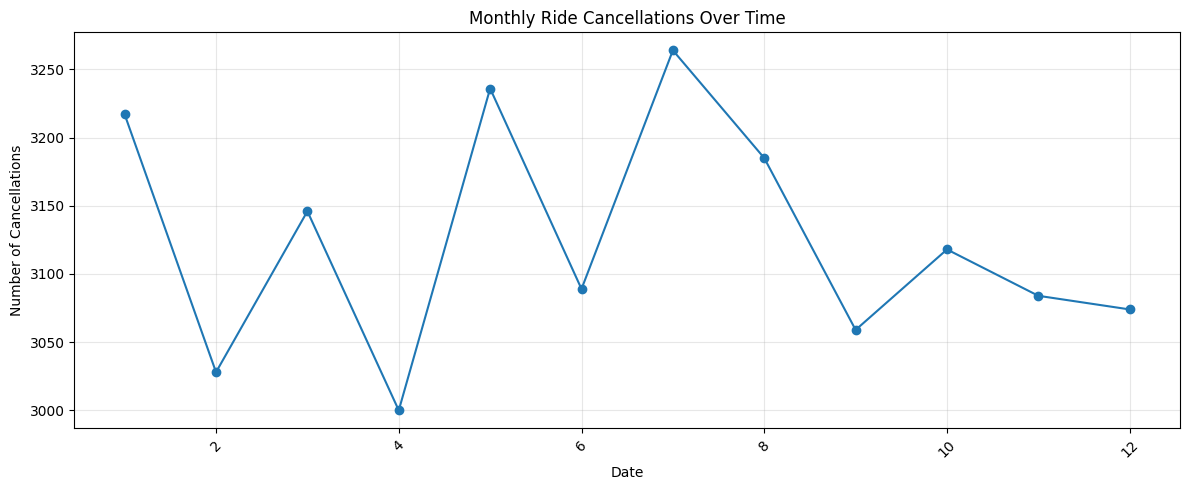

In [32]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_cancellations.index,
    monthly_cancellations.values,
    marker='o',
    linestyle='-'
)

plt.title('Monthly Ride Cancellations Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Cancellations')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Checkpoint:
Objective: Practice thinking like a data scientist by asking a question you find useful and performing some basic EDA.

Task:
- Performance based analysis
- Revenue based analysis
- Location based analysis

Checkpoint response: Revenue based analysis; Which Vehicle Type is responsible for the most "Lost Revenue" due to cancellations?

In [34]:
# filter all unsuccessful rides (Cancellations + No Driver Found)
unsuccessful_rides = processed_df[processed_df['is_successful'] == False]

In [35]:
# calculate Total Lost Revenue by Vehicle Type
# use .sum() on Booking Value column
lost_revenue_by_vehicle = unsuccessful_rides.groupby('Vehicle Type')['Booking Value'].sum().sort_values(ascending=False)

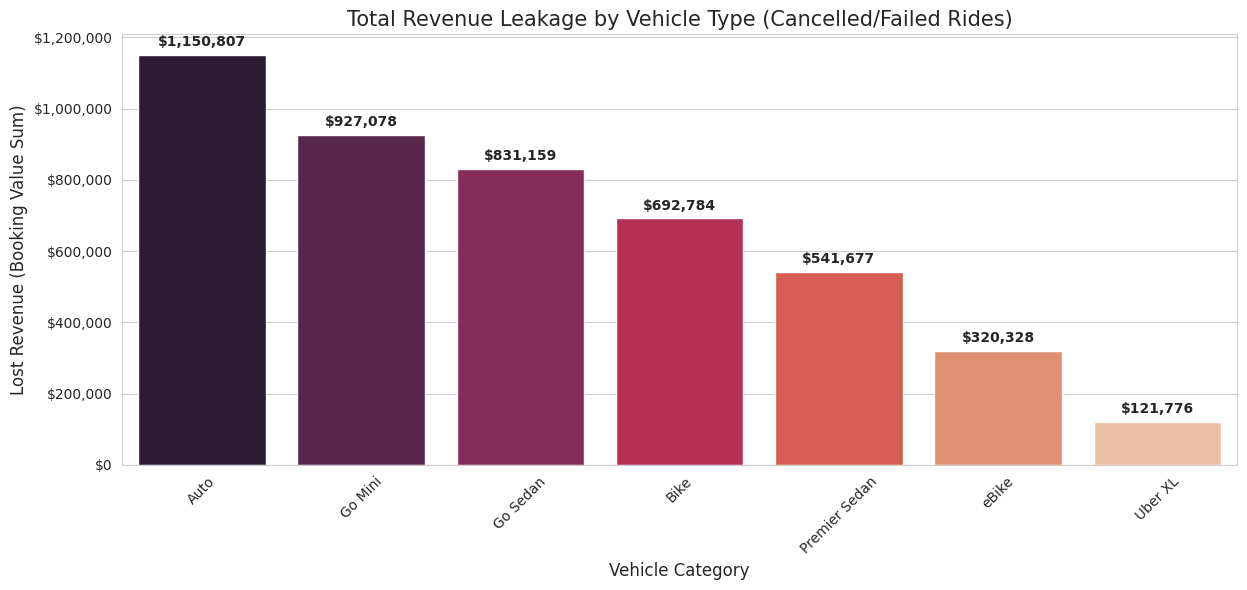

Top Revenue Impact: Auto with $1,150,807.00 in lost bookings.


In [45]:
# create Visulaization
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# plotting
ax = sns.barplot(x=lost_revenue_by_vehicle.index,
                 y=lost_revenue_by_vehicle.values,
                 hue=lost_revenue_by_vehicle.index,
                 palette='rocket',
                 legend=False)

# formatting the chart
plt.title('Total Revenue Leakage by Vehicle Type (Cancelled/Failed Rides)', fontsize=15)
plt.ylabel('Lost Revenue (Booking Value Sum)', fontsize=12)
plt.xlabel('Vehicle Category', fontsize=12)
plt.xticks(rotation=45)

# adding currency labels to the bars
for p in ax.patches:
  ax.annotate(f'${p.get_height():,.0f}',
              (p.get_x() + p.get_width() /2., p.get_height()),
              ha='center', va='center',
              xytext=(0, 9),
              textcoords='offset points',
              fontweight='bold')

plt.tight_layout()
# Format the y-axis as currency with commas
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))
plt.show()

print(f'Top Revenue Impact: {lost_revenue_by_vehicle.idxmax()} with ${lost_revenue_by_vehicle.max():,.2f} in lost bookings.')

Deep Dive into Vehicle Type: Auto

In [38]:
# filter specifically for Auto cancellation
auto_cancelled = processed_df[(processed_df['Vehicle Type'] == 'Auto') &
                              ((processed_df['is_cancelled_customer'] == True) |
                               (processed_df['is_cancelled_driver'] == True))]

In [39]:
# get the breakdown of reasons
auto_driver_reasons = auto_cancelled['Driver Cancellation Reason'].value_counts()
auto_customer_reasons = auto_cancelled['Reason for cancelling by Customer'].value_counts()

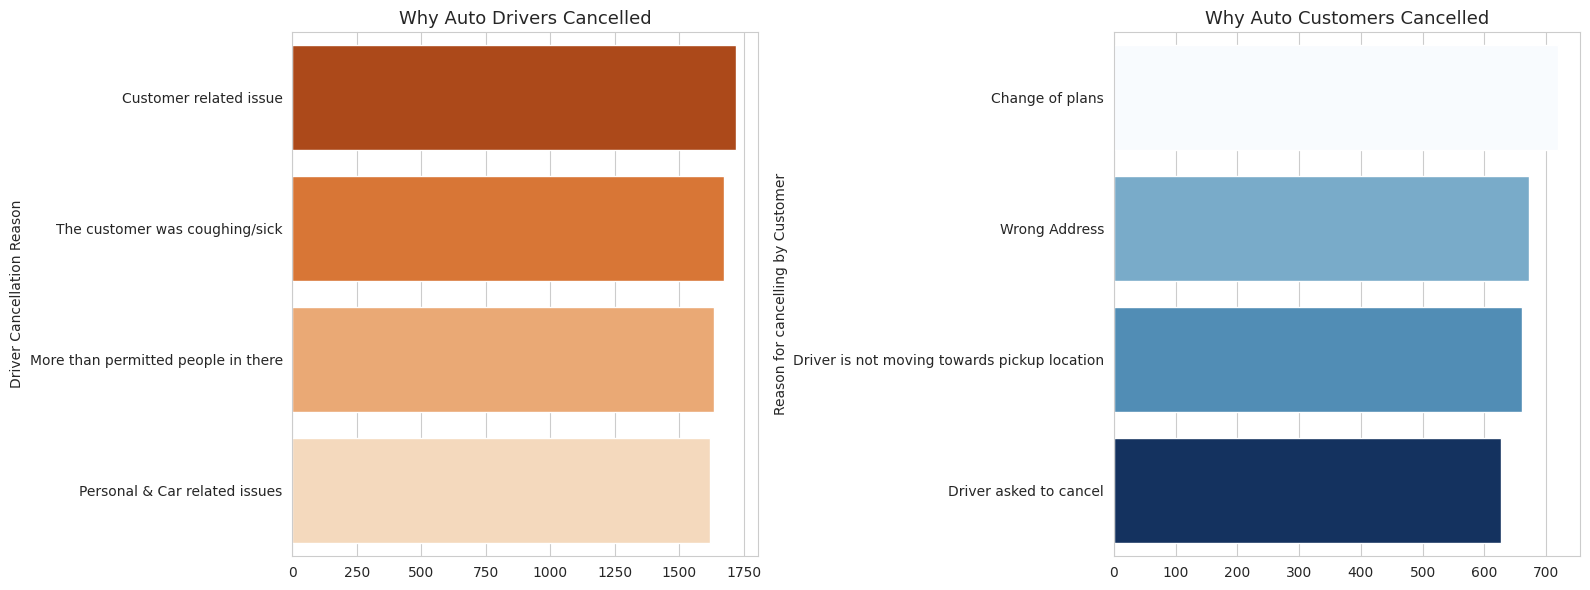

In [42]:
# plotting the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# driver plot
sns.barplot(x=auto_driver_reasons.values,
            y=auto_driver_reasons.index,
            ax=ax1,
            hue=auto_driver_reasons.index,
            palette='Oranges_r',
            legend=False)
ax1.set_title('Why Auto Drivers Cancelled', fontsize=13)

# customer plot
sns.barplot(x=auto_customer_reasons.values,
            y=auto_customer_reasons.index,
            ax=ax2,
            hue=auto_customer_reasons,
            palette='Blues_r',
            legend=False)
ax2.set_title('Why Auto Customers Cancelled', fontsize=13)

plt.tight_layout()
plt.show()

The Auto segment represents the platform's largest revenue leakage, totaling $1,150,807 in unrealized bookings. A deep dive into the cancellation reasons reveals that this financial loss is driven by interface friction rather than a lack of vehicle supply:



*  Demand Friction (Customers): The leading cause of customer cancellations is "Wrong address." This points to a massive UI/UX or GPS accuracy issue. Customers are requesting rides, realizing the pickup or drop-off pin dropped in the wrong location, and abandoning the booking entirely.
*   Supply Friction (Drivers): On the supply side, drivers are primarily cancelling due to "Customer related issues." This strongly correlates with the address problem—drivers arrive at the incorrect GPS pin, cannot locate the passenger, and are forced to cancel the trip after a dispute or waiting period.

